<img src="https://github.com/IOAI-official/IOAI-2025/blob/main/Individual-Contest/Chicken_Counting/figs/IOAI-Logo.png?raw=1" alt="IOAI Logo" width="200" height="auto">

[IOAI 2025 (Beijing, China), Individual Contest](https://ioai-official.org/china-2025)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1zpnSnx0hdni8STy_Jd3HRz7HRY5fqp9M?usp=sharing)

### Imports

In [1]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)                  # Python built-in random
np.random.seed(seed)               # NumPy
torch.manual_seed(seed)            # PyTorch (CPU)
torch.cuda.manual_seed(seed)       # PyTorch (single GPU)
torch.cuda.manual_seed_all(seed)   # PyTorch (all GPUs)

# Ensures deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_from_disk
import logging
from torchvision import transforms
from tqdm import tqdm
import numpy as np
import math

#Contestants should mount "counting_problem_train(v1)" datasets while creating the node.
TRAIN_PATH = "./"  #Address of the training set and base.pth
# The training set is deployed automatically in the testing machine.
# You notebook can access the TRAIN_PATH even if you do not mount it along with notebook.
TRAINING_SET = TRAIN_PATH + "train" #Address of the traninig set
"""BASE_MODEL_PATH = TRAIN_PATH + "base.pth"#Address of the .pth file""" # Not important as we will be using ImageNet weights instead of base.pth
DTYPE = torch.float32
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}, CUDA build: {torch.version.cuda}; using {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else "; CUDA is not available to this kernel"))
scale = 100.0

c:\Users\Ben\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.14.0+cu130, CUDA build: 13.0; using cuda:0 (NVIDIA GeForce RTX 5060 Ti)


### Logging Utilities

In [3]:
def logging_level(level='info'):
    str_format = '%(asctime)s - %(levelname)s: %(message)s'
    if level == 'debug':
        logging.basicConfig(level=logging.DEBUG, format=str_format, datefmt='%Y-%m-%d %H:%M:%S')
    elif level == 'info':
        logging.basicConfig(level=logging.INFO, format=str_format, datefmt='%Y-%m-%d %H:%M:%S')
    return logging


class BatchLossLogger:
    def __init__(self, log_interval=100):
        self.losses = []
        self.batch_number = 0
        self.log_interval = log_interval

    def log(self, loss):
        self.losses.append(loss)
        self.batch_number += 1
        if self.batch_number % self.log_interval == 0:
            logging.info(f'Batch No. {self.batch_number:7d} - loss: {loss:.6f}')

### Training Your Model

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights

class ResNet50Extractor(nn.Module):
    def __init__(self, use_pretrained=True):
        super(ResNet50Extractor, self).__init__()

        weights = ResNet50_Weights.DEFAULT if use_pretrained else None
        resnet = resnet50(weights=weights)

        # Extract layers up to layer4 (dropping the avgpool and fc layers)
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool

        self.layer1 = resnet.layer1  # Outputs 256 channels
        self.layer2 = resnet.layer2  # Outputs 512 channels
        self.layer3 = resnet.layer3  # Outputs 1024 channels
        self.layer4 = resnet.layer4  # Outputs 2048 channels

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        return x

class ResNetDensityDecoder(nn.Module):
    def __init__(self):
        super(ResNetDensityDecoder, self).__init__()
        # ResNet-50 layer4 outputs 2048 channels.
        # We step down the channels gradually.
        self.conv1 = nn.Conv2d(in_channels=2048, out_channels=512, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=512, out_channels=128, kernel_size=3, padding=1)
        # Final output layer for the density map
        self.conv_out = nn.Conv2d(in_channels=128, out_channels=1, kernel_size=1)

    def forward(self, x, target_size):
        x = F.relu(self.conv1(x))
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x = F.relu(self.conv2(x))
        x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)

        x = self.conv_out(x)
        x = F.softplus(x)
        return x

class ChickenCounting(nn.Module):
    def __init__(self, use_pretrained=True):
        super(ChickenCounting, self).__init__()
        self.feature_extraction = ResNet50Extractor(use_pretrained=use_pretrained)
        self.feature_decoder = ResNetDensityDecoder()

    def forward(self, x):
        target_size = (180, 320)

        x = self.feature_extraction(x)

        x = self.feature_decoder(x, target_size=target_size)

        return x

### Reading the Dataset
Read the train dataset

In [5]:
from datasets import load_dataset

# 从 Hugging Face 加载数据集
train_dataset = load_dataset("ioaihsc/Task2_Chicken_Counting_Train2",
                            data_dir="train",
                            split="train")

image_transform = transforms.Compose([
    transforms.ToTensor(),
])

def collate_fn(batch, scale=scale):
    return {
        "image": torch.stack([image_transform(item["image"]) for item in batch]),
        "density": torch.stack([torch.tensor(item["density"], dtype=DTYPE).unsqueeze(0) * scale for item in batch])
    }

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(train_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

### Run Training

In [6]:
def train_chickenfcn(model, train_loader, val_loader, optimizer, scheduler, num_epochs, device, save_path):
    model.train()
    criterion_mse = torch.nn.MSELoss(reduction='sum').to(device)
    criterion_mae = torch.nn.L1Loss(reduction='sum').to(device)
    best_loss = float('inf')
    print(train_loader.__len__())

    history_train_mse = []
    history_val_mse = []

    for epoch in range(num_epochs):
        train_loss_mse = 0.0
        train_loss_mae = 0.0

        train_loader_tqdm = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', leave=False)

        for i, data in enumerate(train_loader_tqdm, 0):
            inputs, targets = data["image"], data["density"]
            inputs = inputs.to(device).float()
            targets = targets.to(device).float()
            # print(targets.shape)
            # t = np.sum((targets[0] / scale).cpu().numpy().squeeze())
            # print(t)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss_mse = criterion_mse(outputs, targets)
            loss_mae = criterion_mae(outputs, targets)
            loss_mae.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

            optimizer.step()
            train_loss_mse += loss_mse.item()
            train_loss_mae += loss_mae.item()

            train_loader_tqdm.set_postfix({'Train MSE Loss': loss_mse.item(), 'Train MAE Loss': loss_mae.item()})

        train_loss_mse /= (len(train_loader))
        train_loss_mae /= (len(train_loader))
        logging.info(
            f'Epoch [{epoch + 1}/{num_epochs}], Train MSE loss: {train_loss_mse:.8f}, MAE loss: {train_loss_mae:.8f}')

        history_train_mse.append(train_loss_mse)

        scheduler.step()

        # Validation
        model.eval()
        val_loss_mse = 0.0
        val_loss_mae = 0.0

        val_loader_tqdm = tqdm(val_loader, desc=f'Validation Epoch {epoch + 1}/{num_epochs}', leave=False)

        with torch.no_grad():
            for i, data in enumerate(val_loader_tqdm, 0):
                inputs, targets = data["image"], data["density"]
                inputs = inputs.to(device).float()
                targets = targets.to(device).float()

                outputs = model(inputs)
                mse_loss = criterion_mse(outputs, targets)
                mae_loss = criterion_mae(outputs, targets)
                val_loss_mse += mse_loss.item()
                val_loss_mae += mae_loss.item()

                val_loader_tqdm.set_postfix(
                    {'Validation MSE Loss': mse_loss.item(), 'Validation MAE Loss': mae_loss.item()})

        val_loss_mse /= (len(val_loader))
        val_loss_mae /= (len(val_loader))
        logging.info(
            f'Epoch [{epoch + 1}/{num_epochs}], Validation MSE Loss: {val_loss_mse:.8f}, MAE Loss: {val_loss_mae:.8f}')

        history_val_mse.append(val_loss_mse)

        # Save Model
        if val_loss_mae < best_loss:
            best_loss = val_loss_mae
            torch.save(model.state_dict(), save_path)

    print('Finished Training ChickenFCN')

    return history_train_mse, history_val_mse

2026-09-29 22:59:29 - INFO: Begin training single view model...


Initialized ResNet-50 with ImageNet weights successfully
13


2026-09-29 22:59:54 - INFO: Epoch [1/20], Train MSE loss: 28606.39978966, MAE loss: 63588.96935096         
2026-09-29 23:00:00 - INFO: Epoch [1/20], Validation MSE Loss: 850.06203827, MAE Loss: 2675.88470337                             
2026-09-29 23:00:08 - INFO: Epoch [2/20], Train MSE loss: 5025.42434458, MAE loss: 18078.94576322          
2026-09-29 23:00:14 - INFO: Epoch [2/20], Validation MSE Loss: 442.84222321, MAE Loss: 1896.50198669                             
2026-09-29 23:00:22 - INFO: Epoch [3/20], Train MSE loss: 2840.01553110, MAE loss: 13040.94257061          
2026-09-29 23:00:28 - INFO: Epoch [3/20], Validation MSE Loss: 274.67738548, MAE Loss: 1481.48479431                          
2026-09-29 23:00:35 - INFO: Epoch [4/20], Train MSE loss: 1868.27766301, MAE loss: 10249.95519081          
2026-09-29 23:00:41 - INFO: Epoch [4/20], Validation MSE Loss: 207.54789948, MAE Loss: 1192.54855591                         
2026-09-29 23:00:49 - INFO: Epoch [5/20], Train MSE los

Finished Training ChickenFCN
Saved training curve to 'mse_training_curve.png'


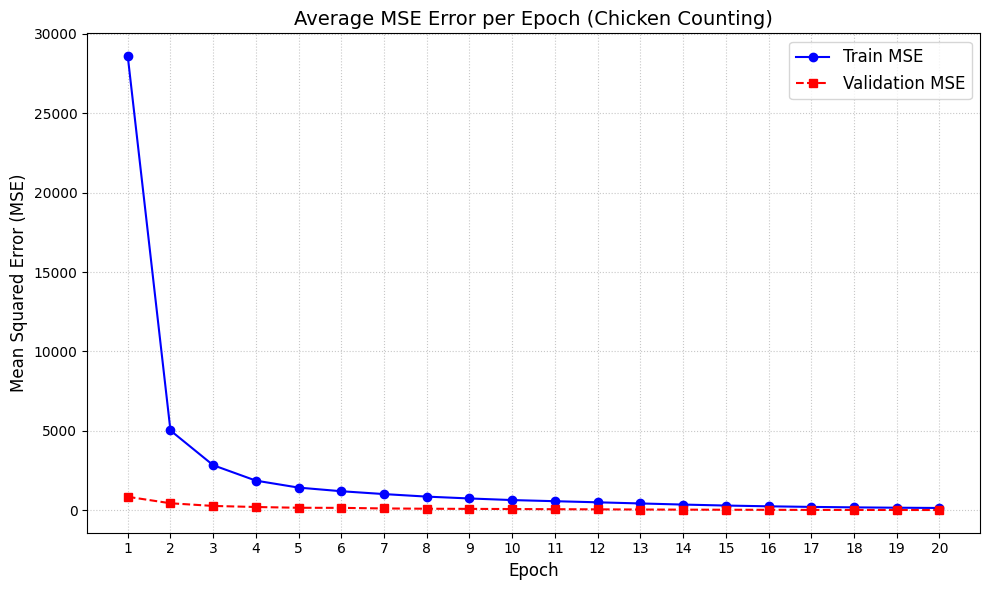

In [7]:
import matplotlib.pyplot as plt
logging = logging_level('info')
logging.debug('use debug level logging setting')

################################################################################
# Experiment Settings
################################################################################
learning_rate = 1e-4
weight_decay = 0.0005
save_path = "resnet_model.pth"
epochs = 20

model = ChickenCounting().to(DEVICE)
print('Initialized ResNet-50 with ImageNet weights successfully')

for param in model.feature_extraction.conv1.parameters(): param.requires_grad = False
for param in model.feature_extraction.bn1.parameters(): param.requires_grad = False
for param in model.feature_extraction.layer1.parameters(): param.requires_grad = False
for param in model.feature_extraction.layer2.parameters(): param.requires_grad = False

trainable_params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.Adam(trainable_params, lr=learning_rate, weight_decay=weight_decay)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.9)

logging.info('Begin training single view model...')
train_mse_history, val_mse_history = train_chickenfcn(
    model, train_loader, val_loader, optimizer, scheduler, epochs, DEVICE, save_path=save_path
)
logging.info('Finished training single view model.')

#-------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot the lines
epochs_range = range(1, epochs + 1)
plt.plot(epochs_range, train_mse_history, marker='o', linestyle='-', color='blue', label='Train MSE')
plt.plot(epochs_range, val_mse_history, marker='s', linestyle='--', color='red', label='Validation MSE')

# Chart formatting
plt.title('Average MSE Error per Epoch (Chicken Counting)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xticks(epochs_range)  # Ensure every epoch is tick-marked
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

# Save and display
plt.tight_layout()
plt.savefig('mse_training_curve.png', dpi=300)
print("Saved training curve to 'mse_training_curve.png'")
plt.show()


### Evaluate Model
This section validates the model on the train set, which helps contestants understand whether the model is usable and calculate the score on the train set.

In [8]:
# Definition of the evaluation function
def evaluate(model, val_loader, device, scale): # Function used for final scoring.
    model.eval()  # Set the model to evaluation mode

    # Initialize metrics
    mse = 0.0
    mae = 0.0
    predict_num = 0.0
    true_num = 0.0
    rate = 0.0

    with torch.no_grad():  # Disable gradient calculation for inference
        for i, data in enumerate(val_loader, 0):
            inputs, targets = data["image"], data["density"]
            inputs = inputs.to(device).float()  # Move inputs to device and convert to float
            targets = targets.to(device).float()  # Move targets to device and convert to float

            # Get the model predictions
            outputs = model(inputs) / scale  # Adjusting for the scaling factor

            # Convert tensors to numpy for visualization and metrics calculation
            inputs_np = inputs.cpu().numpy()  # Convert inputs to numpy
            targets_np = targets.cpu().numpy()  # Convert targets to numpy
            outputs_np = outputs.cpu().numpy()  # Convert outputs to numpy
            # imshow_res(inputs_np, targets_np, outputs_np, scale)  # Uncomment to visualize results

            # Calculate true and predicted sums for comparison
            t = np.sum((targets[0] / scale).cpu().numpy().squeeze())  # Ground truth sum
            g = np.sum(outputs.cpu().numpy().squeeze())  # Predicted sum
            print(f'NO.{i}   true_sum={t}, get_sum={g}, abs={abs(t - g)}, rate={abs(1 - g / t)}')

            # Update metrics
            predict_num += g
            true_num += t
            rate += abs(1 - g / t)
            mae += abs(t - g)
            mse += abs(t - g) * abs(t - g)

    # Calculate average metrics across all batches
    mae /= len(val_loader)
    mse /= len(val_loader)
    predict_num /= len(val_loader)
    true_num /= len(val_loader)
    rate /= len(val_loader)

    # Log the results
    logging.info(
        f'test ---- Score: {math.exp(-rate):.3f}, MSE: {mse:.4f}, MAE: {mae:.4f}, Chicken_avg: {predict_num:.4f}')
    return math.exp(-rate)

In [10]:
model.load_state_dict(torch.load(save_path, map_location=DEVICE))
model.to(DEVICE)
evaluate(model, val_loader, DEVICE, scale)

NO.0   true_sum=25.80451774597168, get_sum=25.60040283203125, abs=0.2041149139404297, rate=0.007910072803497314
NO.1   true_sum=18.838186264038086, get_sum=18.862695693969727, abs=0.024509429931640625, rate=0.0013010501861572266
NO.2   true_sum=19.0, get_sum=18.475910186767578, abs=0.5240898132324219, rate=0.027583658695220947
NO.3   true_sum=18.773645401000977, get_sum=18.775724411010742, abs=0.002079010009765625, rate=0.00011074542999267578
NO.4   true_sum=34.61363983154297, get_sum=34.476959228515625, abs=0.13668060302734375, rate=0.0039487481117248535
NO.5   true_sum=16.0, get_sum=16.158296585083008, abs=0.1582965850830078, rate=0.009893536567687988
NO.6   true_sum=19.820634841918945, get_sum=19.10787582397461, abs=0.7127590179443359, rate=0.03596043586730957
NO.7   true_sum=22.812883377075195, get_sum=22.498653411865234, abs=0.31422996520996094, rate=0.013774216175079346
NO.8   true_sum=19.999853134155273, get_sum=19.864486694335938, abs=0.13536643981933594, rate=0.006768345832824

2026-09-29 23:05:52 - INFO: test ---- Score: 0.988, MSE: 0.3587, MAE: 0.4041, Chicken_avg: 30.2256


NO.97   true_sum=43.887725830078125, get_sum=43.49271011352539, abs=0.3950157165527344, rate=0.009000599384307861
NO.98   true_sum=31.656579971313477, get_sum=31.94035530090332, abs=0.28377532958984375, rate=0.008964180946350098
NO.99   true_sum=26.9598445892334, get_sum=26.79674530029297, abs=0.1630992889404297, rate=0.006049692630767822


0.987802578691149

### Submission
This part is to generate the result files for testing and scoring.
Contestants couldn't access the validation set(test_a) and the test set(test_b) locally.
Please read through the following code carefully. Make sure to following the file naming conventions.

In [ ]:
from datasets import load_dataset

test_dataset = load_dataset("ioaihsc/Task2_Chicken_Counting_Test",
                            data_dir="valandtest",
                            split="validation")

def collate_fn(batch): # The test datasets will not provide target densities
    return torch.stack([image_transform(item["image"]) for item in batch])

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

predictions = []
model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader):
        outputs = model(batch.to(DEVICE)) / scale
        predictions.append(outputs.cpu().numpy())

pred_a = np.concatenate(predictions, axis=0)

del test_dataset
del test_loader
del predictions

test_dataset = load_dataset("ioaihsc/Task2_Chicken_Counting_Test",
                            data_dir="valandtest",
                            split="test")
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

predictions = []
with torch.no_grad():
    for batch in tqdm(test_loader):
        outputs = model(batch.to(DEVICE)) / scale
        predictions.append(outputs.cpu().numpy())

pred_b = np.concatenate(predictions, axis=0)

np.savez('submission.npz', pred_a=pred_a, pred_b=pred_b) # save your submissions in `submission.npz` file with the keys `pred_a` and `pred_b`

README.md:   0%|          | 0.00/446 [00:00<?, ?B/s]

valandtest/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B /  167MB            

valandtest/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

valandtest/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  168MB            

valandtest/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

100%|██████████| 7/7 [00:11<00:00,  1.61s/it]


In [ ]:
%run ./metrics.py

README.md:   0%|          | 0.00/480 [00:00<?, ?B/s]

valandtest/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 9.28MB            

valandtest/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

valandtest/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 9.12MB            

valandtest/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

<Figure size 640x480 with 0 Axes>